In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# Drive 마운트 전이면 아래가 실패할 수 있습니다.
# (셀 4에서 drive.mount 실행 후) 다시 이 셀을 실행하거나,
# 아래 셀(10)에서 PATHS로 로드하는 흐름을 사용하세요.
try:
    df = pd.read_csv("/content/drive/MyDrive/허정인/data/train.csv")
    display(df.head())
except Exception as e:
    print("Drive 마운트 후 다시 실행하세요. 에러:", type(e).__name__, str(e)[:120])

,img_id,img_path,mask_rle
0,TRAIN_0000,./train_img/TRAIN_0000.png,9576 7 10590 17 11614 17 12638 17 13662 17 146...
1,TRAIN_0001,./train_img/TRAIN_0001.png,208402 1 209425 6 210449 10 211473 14 212497 1...
2,TRAIN_0002,./train_img/TRAIN_0002.png,855 34 15654 9 16678 9 16742 8 17702 9 17766 9...
3,TRAIN_0003,./train_img/TRAIN_0003.png,362 6 745 15 798 22 900 25 1385 8 1828 16 1924...
4,TRAIN_0004,./train_img/TRAIN_0004.png,34 27 1058 27 2082 27 3105 27 4129 27 5153 27 ...


In [ ]:
# 런타임/장치 확인
import os, platform, psutil, torch

print("Python:", platform.python_version())
print("CPU cores:", os.cpu_count())
print("RAM(GB):", round(psutil.virtual_memory().total/1024**3, 2))

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM(GB):", round(torch.cuda.get_device_properties(0).total_memory/1024**3, 2))


Python: 3.12.12
CPU cores: 8
RAM(GB): 50.99
CUDA available: True
GPU: Tesla T4
VRAM(GB): 14.74


In [ ]:
# 1. 기존 패키지 삭제
!pip uninstall -y torch torchvision torchaudio segmentation-models-pytorch

# 2. 캐시 없이 다시 설치 (최신 안정화 버전)
!pip install --no-cache-dir torch torchvision torchaudio segmentation-models-pytorch

Found existing installation: torch 2.9.0+cu126
Uninstalling torch-2.9.0+cu126:
  Successfully uninstalled torch-2.9.0+cu126
Found existing installation: torchvision 0.24.0+cu126
Uninstalling torchvision-0.24.0+cu126:
  Successfully uninstalled torchvision-0.24.0+cu126
Found existing installation: torchaudio 2.9.0+cu126
Uninstalling torchaudio-2.9.0+cu126:
  Successfully uninstalled torchaudio-2.9.0+cu126
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.7/915.7 MB 57.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 56.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 263.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 406.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 332.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import segmentation_models_pytorch as smp

In [ ]:
import sys
import importlib, pkgutil

In [ ]:
import sys
print('python:', sys.executable)
import importlib, pkgutil
print('has segmentation_models_pytorch package?', pkgutil.find_loader('segmentation_models_pytorch') is not None)
try:
    import segmentation_models_pytorch as smp
    print('smp version:', getattr(smp, '__version__', 'unknown'))
except Exception as e:
    print('IMPORT FAILED:', repr(e))
    # 설치 직후라면 런타임/커널 재시작 후 다시 실행하세요.


python: /usr/bin/python3
has segmentation_models_pytorch package? True
smp version: 0.5.0


/tmp/ipython-input-406296207.py:4: DeprecationWarning: 'pkgutil.find_loader' is deprecated and slated for removal in Python 3.14; use importlib.util.find_spec() instead
  print('has segmentation_models_pytorch package?', pkgutil.find_loader('segmentation_models_pytorch') is not None)


## 1) 경로 설정 (Drive만 사용)

- **로컬(`/content`) 캐시를 사용하지 않고**, Drive에서 바로 읽는 흐름으로 구성합니다.
- 대신 전처리 작업(특히 타일링)은 **병렬화(num_workers / n_jobs)** 를 적극 활용해 속도를 끌어올립니다.


In [ ]:
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

# ===== Drive 경로: 본인 프로젝트에 맞게 수정 =====
PATHS = {
    "train_csv": "/content/drive/MyDrive/허정인/data/train.csv",
    "train_img_dir": "/content/drive/MyDrive/허정인/data",
    "out_dir": "/content/drive/MyDrive/허정인/data/preprocessed",
    "test_csv": "/content/drive/MyDrive/허정인/data/test.csv",
    "test_img_dir": "/content/drive/MyDrive/허정인/data",
}
os.makedirs(PATHS["out_dir"], exist_ok=True)

print(PATHS)

{'train_csv': '/content/drive/MyDrive/허정인/data/train.csv', 'train_img_dir': '/content/drive/MyDrive/허정인/data', 'out_dir': '/content/drive/MyDrive/허정인/data/preprocessed', 'test_csv': '/content/drive/MyDrive/허정인/data/test.csv', 'test_img_dir': '/content/drive/MyDrive/허정인/data'}


## 2) Drive → 로컬 SSD로 데이터 복사 (Colab Pro 활용 포인트)

Drive에서 바로 읽으면 `cv2.imread`가 느려지고, 타일링 같은 전처리는 시간이 크게 늘어납니다.  
**한 번 로컬로 복사한 뒤** 전처리/학습을 돌리면 속도가 눈에 띄게 빨라집니다.


In [ ]:
# ✅ 로컬 캐시/복사 없이 진행합니다.
# Drive 경로가 올바른지만 빠르게 체크합니다.

import os

assert os.path.isfile(PATHS["train_csv"]), f"train.csv not found: {PATHS['train_csv']}"
assert os.path.isdir(PATHS["train_img_dir"]), f"train_img_dir not found: {PATHS['train_img_dir']}"
assert os.path.isfile(PATHS["test_csv"]), f"test.csv not found: {PATHS['test_csv']}"
assert os.path.isdir(PATHS["test_img_dir"]), f"test_img_dir not found: {PATHS['test_img_dir']}"

print("OK - train.csv:", PATHS["train_csv"])
print("OK - train_img_dir:", PATHS["train_img_dir"])
print("num images:", len(os.listdir(PATHS["train_img_dir"])))

import os

def resolve_img_path(img_dir, rel_path):
    p = str(rel_path).replace("\\", "/")
    p = p.lstrip("./")  # "./train_img/..." -> "train_img/..."

    # 이미 절대경로면 그대로
    if p.startswith("/"):
        return p

    # img_dir이 .../train_img 인데 p도 train_img/...면 중복 방지 위해 parent 붙이기
    if os.path.basename(img_dir.rstrip("/")) == "train_img" and p.startswith("train_img/"):
        return os.path.join(os.path.dirname(img_dir), p)

    # 그 외는 그냥 join
    return os.path.join(img_dir, p)

OK - train.csv: /content/drive/MyDrive/허정인/data/train.csv
OK - train_img_dir: /content/drive/MyDrive/허정인/data
num images: 7


## 3) train.csv 로드 & 기본 점검


In [ ]:
df = pd.read_csv(PATHS["train_csv"])
print(df.head())
print("\ncolumns:", df.columns.tolist())
print("\nrows:", len(df))

# 기대 컬럼:
# - img_path: 이미지 파일명 또는 상대 경로
# - mask_rle: RLE 문자열 또는 -1(마스크 없음)

       img_id                    img_path  \
0  TRAIN_0000  ./train_img/TRAIN_0000.png   
1  TRAIN_0001  ./train_img/TRAIN_0001.png   
2  TRAIN_0002  ./train_img/TRAIN_0002.png   
3  TRAIN_0003  ./train_img/TRAIN_0003.png   
4  TRAIN_0004  ./train_img/TRAIN_0004.png   

                                            mask_rle  
0  9576 7 10590 17 11614 17 12638 17 13662 17 146...  
1  208402 1 209425 6 210449 10 211473 14 212497 1...  
2  855 34 15654 9 16678 9 16742 8 17702 9 17766 9...  
3  362 6 745 15 798 22 900 25 1385 8 1828 16 1924...  
4  34 27 1058 27 2082 27 3105 27 4129 27 5153 27 ...  

columns: ['img_id', 'img_path', 'mask_rle']

rows: 7140


## 4) Train/Val Split 생성 (재현 가능 Seed) + Drive에도 저장

- 로컬에 split 저장 → 학습에서 빠르게 사용
- 동시에 Drive에도 저장 → 세션 끊겨도 보존


In [ ]:
from sklearn.model_selection import train_test_split
import os
import pandas as pd

SEED = 11
VAL_RATIO = 0.2

train_split_path = os.path.join(PATHS["out_dir"], "train_split.csv")
val_split_path   = os.path.join(PATHS["out_dir"], "val_split.csv")

# ✅ 공정 비교를 위해: split 파일이 이미 있으면 "로드"해서 고정 사용
if os.path.exists(train_split_path) and os.path.exists(val_split_path):
    train_df = pd.read_csv(train_split_path)
    val_df   = pd.read_csv(val_split_path)
    print("loaded existing split:")
else:
    train_df, val_df = train_test_split(df, test_size=VAL_RATIO, random_state=SEED, shuffle=True)
    train_df.to_csv(train_split_path, index=False)
    val_df.to_csv(val_split_path, index=False)
    print("created & saved new split:")

print("train_split_path:", train_split_path)
print("val_split_path  :", val_split_path)
print("train/val:", len(train_df), len(val_df))


loaded existing split:
train_split_path: /content/drive/MyDrive/허정인/data/preprocessed/train_split.csv
val_split_path  : /content/drive/MyDrive/허정인/data/preprocessed/val_split.csv
train/val: 5712 1428


## 5) RLE Decode/Encode 유틸 (mask_rle = -1 처리 포함)

In [ ]:
from typing import Union, Tuple

def rle_decode(mask_rle: Union[str, int, float], shape: Tuple[int,int]) -> np.ndarray:
    if mask_rle is None:
        return np.zeros(shape, dtype=np.uint8)
    if isinstance(mask_rle, float) and np.isnan(mask_rle):
        return np.zeros(shape, dtype=np.uint8)
    if mask_rle == -1 or mask_rle == "-1":
        return np.zeros(shape, dtype=np.uint8)

    s = str(mask_rle).split()
    starts, lengths = [np.asarray(x, dtype=int) for x in (s[0::2], s[1::2])]
    starts -= 1
    ends = starts + lengths

    img = np.zeros(shape[0]*shape[1], dtype=np.uint8)
    for lo, hi in zip(starts, ends):
        img[lo:hi] = 1
    return img.reshape(shape)

def rle_encode(mask: np.ndarray) -> Union[str, int]:
    pixels = mask.astype(np.uint8).flatten()
    if pixels.sum() == 0:
        return -1
    pixels = np.concatenate([[0], pixels, [0]])
    runs = np.where(pixels[1:] != pixels[:-1])[0] + 1
    runs[1::2] -= runs[::2]
    return " ".join(str(x) for x in runs)


## (추가) Dice 기반 평가 통일

- **학습 손실(loss)**: `DiceLoss = 1 - soft dice` (threshold 없이 확률로 계산)
- **평가 지표(metric)**: `Dice score` (sigmoid 후 threshold=0.5)

> 회의 결론대로 **DiceLoss로 통일 + 로그에 Dice score(또는 1-Dice)** 를 같이 기록합니다.


In [ ]:
import torch

def dice_coef_from_logits(logits, targets, threshold=0.5, eps=1e-7):
    """Dice score (0~1), logits -> sigmoid -> threshold"""
    if targets.dim() == 3:
        targets = targets.unsqueeze(1)

    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    preds = preds.view(preds.size(0), -1)
    targets = targets.float().view(targets.size(0), -1)

    inter = (preds * targets).sum(dim=1)
    sums = preds.sum(dim=1) + targets.sum(dim=1)

    dice = (2 * inter + eps) / (sums + eps)
    # 둘 다 빈 마스크면 dice=1로 처리 (대회/세그먼트 평가 관행)
    dice = torch.where(sums > 0, dice, torch.ones_like(dice))
    return dice.mean()

def soft_dice_loss_from_logits(logits, targets, eps=1e-7):
    """Soft Dice Loss = 1 - soft dice (학습용)"""
    if targets.dim() == 3:
        targets = targets.unsqueeze(1)

    probs = torch.sigmoid(logits)
    probs = probs.view(probs.size(0), -1)
    targets = targets.float().view(targets.size(0), -1)

    inter = (probs * targets).sum(dim=1)
    sums = probs.sum(dim=1) + targets.sum(dim=1)

    dice = (2 * inter + eps) / (sums + eps)
    dice = torch.where(sums > 0, dice, torch.ones_like(dice))
    return 1 - dice.mean()


@torch.no_grad()
def prf_iou_from_logits(logits, targets, threshold=0.5, eps=1e-7):
    # shapes 맞추기
    if targets.dim() == 3:
        targets = targets.unsqueeze(1)
    if logits.dim() == 3:
        logits = logits.unsqueeze(1)

    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()
    targets = targets.float()

    # flatten: (B, H*W)
    preds_f = preds.view(preds.size(0), -1)
    targs_f = targets.view(targets.size(0), -1)

    tp = (preds_f * targs_f).sum(dim=1)
    fp = (preds_f * (1 - targs_f)).sum(dim=1)
    fn = ((1 - preds_f) * targs_f).sum(dim=1)

    precision = (tp + eps) / (tp + fp + eps)
    recall    = (tp + eps) / (tp + fn + eps)
    f1        = (2 * precision * recall + eps) / (precision + recall + eps)  # = Dice
    iou       = (tp + eps) / (tp + fp + fn + eps)

    # 배치 평균 scalar 반환
    return precision.mean(), recall.mean(), f1.mean(), iou.mean()


In [ ]:
import torch.nn as nn

# ===== Loss functions for fair comparison =====
bce_loss_fn = nn.BCEWithLogitsLoss()

def loss_bce(logits, y):
    if y.dim() == 3:
        y = y.unsqueeze(1)
    return bce_loss_fn(logits, y.float())

def loss_dice(logits, y):
    return soft_dice_loss_from_logits(logits, y)

def loss_bce_plus_dice(logits, y, alpha=1.0, beta=1.0):
    return alpha * loss_bce(logits, y) + beta * loss_dice(logits, y)

LOSS_DICT = {
    "BCE": loss_bce,
    "Dice": loss_dice,
    "BCE + Dice": lambda logits, y: loss_bce_plus_dice(logits, y, alpha=1.0, beta=1.0),
}
print("Loss functions ready:", list(LOSS_DICT.keys()))


Loss functions ready: ['BCE', 'Dice', 'BCE + Dice']


In [ ]:
import numpy as np, os, gc, copy
import torch
import segmentation_models_pytorch as smp

def make_model_fn():
    # ✅ loss별로 "완전히 동일한 초기 조건"으로 모델을 새로 만들기 위함
    return smp.FPN(
        encoder_name="efficientnet-b5",
        encoder_weights="imagenet",
        in_channels=3,
        classes=1,
    )

@torch.no_grad()
def eval_metrics_dataset_level(model, loader, threshold=0.5, eps=1e-7):
    """
    배치 평균(mean of batch means) 대신,
    전체 validation set에서 TP/FP/FN을 누적해서 dataset-level로 계산 (더 안정적)
    """
    model.eval()
    TP = FP = FN = 0.0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        if y.dim() == 3:
            y = y.unsqueeze(1)
        y = y.float()

        logits = model(x)
        probs = torch.sigmoid(logits)
        preds = (probs > float(threshold)).float()

        preds_f = preds.view(preds.size(0), -1)
        y_f     = y.view(y.size(0), -1)

        TP += (preds_f * y_f).sum().item()
        FP += (preds_f * (1 - y_f)).sum().item()
        FN += ((1 - preds_f) * y_f).sum().item()

    precision = (TP + eps) / (TP + FP + eps)
    recall    = (TP + eps) / (TP + FN + eps)
    dice_f1   = (2 * precision * recall + eps) / (precision + recall + eps)
    iou       = (TP + eps) / (TP + FP + FN + eps)

    return float(precision), float(recall), float(dice_f1), float(iou)


In [ ]:
import os, time, copy, inspect
import numpy as np
import pandas as pd
import torch

def run_experiment(
    loss_name, loss_fn,
    EPOCHS=5, lr=1e-4, weight_decay=1e-5, threshold=0.5,
    SAVE_PTH=False,          # 빠른 비교: False, 최종: True
    RETURN_BEST_MODEL=True,
    save_history_csv=False
):
    model = make_model_fn().to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    # 있으면 사용, 없으면 None
    scheduler = globals().get("scheduler", None)

    history = []
    best_epoch = -1
    best_score = -1e18
    best_state = None

    os.makedirs(PATHS["out_dir"], exist_ok=True)
    best_model_path = os.path.join(PATHS["out_dir"], f"best_{loss_name.replace(' ', '_')}.pth")

    t0 = time.time()

    # --- 시그니처 기반으로 인자 자동 맞춤 ---
    sig_train = inspect.signature(train_one_epoch)
    sig_val   = inspect.signature(validate)

    train_params = list(sig_train.parameters.keys())
    val_params   = list(sig_val.parameters.keys())

    def _call_epoch_fn(fn, params, mode, epoch):
        """
        mode: 'train' or 'val'
        네 노트북 함수 시그니처에 맞춰 args/kwargs 구성해서 호출
        """
        kwargs = {}
        if "loss_fn" in params:
            kwargs["loss_fn"] = loss_fn
        if "threshold" in params:
            kwargs["threshold"] = threshold

        # 기본 args 구성
        if mode == "train":
            args = [model, train_loader, optimizer]
        else:
            args = [model, val_loader]

        # optimizer를 val이 받는 경우도 있음
        if (mode == "val") and ("optimizer" in params):
            # validate(model, loader, optimizer, ...) 스타일 대응
            args.append(optimizer)

        # scheduler가 필요한 경우
        if "scheduler" in params:
            args.append(scheduler)

        # epoch / total_epochs(또는 EPOCHS) 필수 대응
        if "epoch" in params:
            args.append(epoch)

        if "total_epochs" in params:
            args.append(EPOCHS)
        elif "EPOCHS" in params:
            args.append(EPOCHS)

        return fn(*args, **kwargs)

    for epoch in range(1, EPOCHS + 1):
        # ---- TRAIN ----
        tr_out = _call_epoch_fn(train_one_epoch, train_params, mode="train", epoch=epoch)

        # ---- VAL ----
        va_out = _call_epoch_fn(validate, val_params, mode="val", epoch=epoch)

        # ---- 반환값 파싱(너 노트북 반환 형태가 여러 가지일 수 있어서 최대한 안전하게) ----
        # 보통 (loss, dice, iou, ...) 또는 (loss, dice, iou) 형태
        def _parse(out):
            if isinstance(out, (list, tuple)):
                loss = out[0]
                dice = out[1] if len(out) > 1 else None
                iou  = out[2] if len(out) > 2 else None
            else:
                loss, dice, iou = out, None, None
            return loss, dice, iou

        tr_loss, tr_dice, tr_iou = _parse(tr_out)
        va_loss, va_dice, va_iou = _parse(va_out)

        # best 기준 점수: iou가 있으면 iou, 없으면 dice
        score = va_iou if (va_iou is not None) else (va_dice if va_dice is not None else -1e18)

        history.append({
            "epoch": epoch,
            "tr_loss": float(tr_loss) if tr_loss is not None else np.nan,
            "tr_dice": float(tr_dice) if tr_dice is not None else np.nan,
            "tr_iou":  float(tr_iou)  if tr_iou  is not None else np.nan,
            "va_loss": float(va_loss) if va_loss is not None else np.nan,
            "va_dice": float(va_dice) if va_dice is not None else np.nan,
            "va_iou":  float(va_iou)  if va_iou  is not None else np.nan,
        })

        print(f"[{loss_name}] Epoch {epoch}/{EPOCHS} | "
              f"tr_loss={float(tr_loss):.4f} va_loss={float(va_loss):.4f} | best_score={float(score):.4f}")

        # ✅ best 갱신: 디스크 저장/로드 없이 메모리에만 deepcopy
        if float(score) > float(best_score):
            best_score = float(score)
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())

    history_df = pd.DataFrame(history)
    best_row = history_df.loc[history_df["epoch"] == best_epoch].iloc[0]

    # (선택) 최종에만 pth 저장
    if SAVE_PTH and (best_state is not None):
        torch.save(best_state, best_model_path)

    # ✅ best_model 반환(디스크 로드 없음)
    best_model = None
    if RETURN_BEST_MODEL:
        best_model = make_model_fn().to(device)
        best_model.load_state_dict(best_state if best_state is not None else model.state_dict())
        best_model.eval()

    # summary (너 그래프 코드 컬럼명 유지)
    summary = {
        "loss": loss_name,
        "EPOCHS": int(EPOCHS),
        "lr": float(lr),
        "weight_decay": float(weight_decay),
        "best_epoch_by_val_iou(th=0.5log)": int(best_epoch),
        "best_model_path": best_model_path,
        "best_threshold_by_val_iou": float(threshold),
        "val_iou@best_th": float(best_row["va_iou"]) if not np.isnan(best_row["va_iou"]) else float(best_row["va_dice"]),
        "val_dice@best_th": float(best_row["va_dice"]),
        "eval_threshold_used": float(threshold),
        "note": "no torch.load; train/val both receive epoch,total_epochs",
        "total_time_sec": float(time.time() - t0),
        "pth_saved": bool(SAVE_PTH),
    }

    if save_history_csv:
        hist_path = os.path.join(PATHS["out_dir"], f"history_{loss_name.replace(' ', '_')}.csv")
        history_df.to_csv(hist_path, index=False)

    return {
        "history_df": history_df,
        "summary": summary,
        "best_model": best_model,
        "best_state": best_state,
    }


## 6) 샘플 확인 (overlay 시각화)

로컬 SSD에서 읽으므로 훨씬 빠르게 확인 가능합니다.


image: (1024, 1024, 3) mask sum: 24514


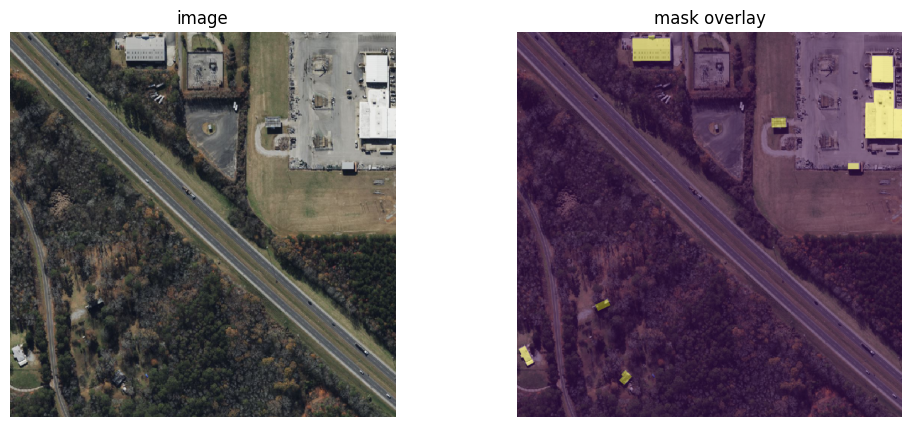

In [ ]:
row = df.iloc[0]
img_path = resolve_img_path(PATHS["train_img_dir"], row["img_path"])
img = cv2.imread(img_path)
if img is None:
    raise FileNotFoundError(img_path)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
H, W = img.shape[:2]
mask = rle_decode(row["mask_rle"], (H, W))

print("image:", img.shape, "mask sum:", int(mask.sum()))

plt.figure(figsize=(12,5))
plt.subplot(1,2,1); plt.title("image"); plt.imshow(img); plt.axis("off")
plt.subplot(1,2,2); plt.title("mask overlay"); plt.imshow(img); plt.imshow(mask, alpha=0.4); plt.axis("off")
plt.show()


## 7) RandomCrop Dataset + DataLoader 최적화

Colab Pro는 CPU 코어가 더 많은 경우가 많아서 `num_workers`를 올리면 빨라집니다.  
권장: `num_workers = min(8, os.cpu_count())` 정도부터 시작.


In [ ]:
import random
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

def seed_everything(seed=11):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

# 서영님 전처리에서 변경사항-> MEAN, STD
# EfficientNet-B7같은 고성능 모델은 ImageNet이라는 데이터셋으로 학습돼있어서 기준값이 따로 있어서 재설정.
CROP_SIZE = 512
MEAN = (0.485, 0.456, 0.406)
STD = (0.229, 0.224, 0.225)

train_tf = A.Compose([
    A.PadIfNeeded(min_height=CROP_SIZE, min_width=CROP_SIZE, border_mode=cv2.BORDER_CONSTANT, value=0),
    A.RandomCrop(CROP_SIZE, CROP_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5), # 위성 이미지는 회전해도 무방하므로 추가
    A.RandomBrightnessContrast(p=0.2), # 날씨/조명 차이 대비
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

val_tf = A.Compose([
    A.PadIfNeeded(min_height=CROP_SIZE, min_width=CROP_SIZE, border_mode=cv2.BORDER_CONSTANT, value=0),
    A.CenterCrop(CROP_SIZE, CROP_SIZE),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

class SatelliteDataset(Dataset):
    def __init__(self, df, img_dir, transform=None, infer=False):
        self.df = df.reset_index(drop=True).copy()
        self.img_dir = img_dir
        self.transform = transform
        self.infer = infer

        # 최소 컬럼 체크
        if "img_path" not in self.df.columns:
            raise ValueError("CSV에 'img_path' 컬럼이 없습니다.")
        if (not infer) and ("mask_rle" not in self.df.columns):
            raise ValueError("CSV에 'mask_rle' 컬럼이 없습니다. (infer=False일 때 필요)")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        r = self.df.iloc[idx]
        img_path = resolve_img_path(self.img_dir, r["img_path"])
        img = cv2.imread(img_path)
        if img is None:
            raise FileNotFoundError(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        H, W = img.shape[:2]

        if self.infer:
            mask = np.zeros((H, W), dtype=np.uint8)
        else:
            mask = rle_decode(r["mask_rle"], (H, W)).astype(np.uint8)

        if self.transform is not None:
            out = self.transform(image=img, mask=mask)
            img_t = out["image"]                  # (C,H,W), float32
            mask_t = out["mask"].float()          # (H,W)
        else:
            img_t = torch.from_numpy(img).permute(2,0,1).float() / 255.0
            mask_t = torch.from_numpy(mask).float()


        mask_t = (mask_t > 0.5).float()
        return img_t, mask_t

# Dataset / DataLoader
train_ds = SatelliteDataset(train_df, PATHS["train_img_dir"], transform=train_tf, infer=False)
val_ds   = SatelliteDataset(val_df,   PATHS["train_img_dir"], transform=val_tf,   infer=False)

# 서영님 전처리에서 변경사항 -> num_workers
# RAM 부족 문제로 8->0으로 수정
num_workers = 0

# 서영님 전처리에서 변경사항 -> batch_size
# 기존 U-Net 모델보다 큰 모델이어서 batch_size를 줄임(8->2)
train_loader_kwargs = dict(
    batch_size=2,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True,
)
val_loader_kwargs = dict(
    batch_size=2,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True,
)

# 전처리 변경사항 -> 뒷 부분 코드 주석처리
# 메모리 점유 방지
#if num_workers > 0:
    #train_loader_kwargs.update(dict(persistent_workers=True, prefetch_factor=2))
    #val_loader_kwargs.update(dict(persistent_workers=True, prefetch_factor=2))

train_loader = DataLoader(train_ds, **train_loader_kwargs)
val_loader   = DataLoader(val_ds,   **val_loader_kwargs)

x, y = next(iter(train_loader))
print("batch image:", x.shape, "batch mask:", y.shape, "unique mask values:", torch.unique(y))


/tmp/ipython-input-3046279259.py:22: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(min_height=CROP_SIZE, min_width=CROP_SIZE, border_mode=cv2.BORDER_CONSTANT, value=0),
/tmp/ipython-input-3046279259.py:33: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(min_height=CROP_SIZE, min_width=CROP_SIZE, border_mode=cv2.BORDER_CONSTANT, value=0),


batch image: torch.Size([2, 3, 512, 512]) batch mask: torch.Size([2, 512, 512]) unique mask values: tensor([0., 1.])


## 8) 타일링 CSV 생성 — **멀티프로세싱 병렬화**

- 전처리에서 가장 오래 걸리는 건 **RLE decode + 이미지 read(I/O)** 입니다.
- 로컬 SSD로 옮긴 뒤, **프로세스를 여러 개** 띄워 병렬로 돌리면 체감이 큽니다.

생성 결과는 로컬 + Drive 둘 다 저장하도록 했습니다.


In [ ]:
from joblib import Parallel, delayed
from tqdm import tqdm
import os
import pandas as pd
"""
def _process_one_image(r, img_dir, tile, stride):
    img_path = resolve_img_path(PATHS["train_img_dir"], row["img_path"])
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(img_path)
    H, W = img.shape[:2]
    full_mask = rle_decode(r["mask_rle"], (H, W))

    rows = []
    for y0 in range(0, H - tile + 1, stride):
        for x0 in range(0, W - tile + 1, stride):
            tile_mask = full_mask[y0:y0+tile, x0:x0+tile]
            tile_rle = rle_encode(tile_mask)
            rows.append({
                "img_path": r["img_path"],
                "mask_rle": tile_rle,
                "x": x0,
                "y": y0,
                "tile": tile,
                "H": H,
                "W": W
            })
    return rows

def build_tiles_csv_mp(df_in: pd.DataFrame, csv_out: str, img_dir: str,
                       tile: int = 256, stride: int = 256, n_jobs: int = 8):
    records = df_in.to_dict("records")
    n_jobs = min(n_jobs, os.cpu_count())

    all_rows = Parallel(n_jobs=n_jobs, backend="loky")(
        delayed(_process_one_image)(r, img_dir, tile, stride) for r in tqdm(records)
    )
    flat = [item for sub in all_rows for item in sub]
    out_df = pd.DataFrame(flat)
    out_df.to_csv(csv_out, index=False)
    return out_df

TILE = 256
STRIDE = 256   # 겹치게 하려면 128 같은 값도 시도 (다만 Drive I/O가 더 느릴 수 있음)
N_JOBS = min(12, os.cpu_count())

train_tiles_path = os.path.join(PATHS["out_dir"], f"train_tiles_{TILE}_s{STRIDE}.csv")
val_tiles_path   = os.path.join(PATHS["out_dir"], f"val_tiles_{TILE}_s{STRIDE}.csv")

# 필요할 때만 실행 (시간 걸림)
# train_tiles_df = build_tiles_csv_mp(train_df, train_tiles_path, PATHS["train_img_dir"], tile=TILE, stride=STRIDE, n_jobs=N_JOBS)
# val_tiles_df   = build_tiles_csv_mp(val_df,   val_tiles_path,   PATHS["train_img_dir"], tile=TILE, stride=STRIDE, n_jobs=N_JOBS)

print("tiles csv paths:")
print(" -", train_tiles_path)
print(" -", val_tiles_path)
"""


'\ndef _process_one_image(r, img_dir, tile, stride):\n    img_path = resolve_img_path(PATHS["train_img_dir"], row["img_path"])\n    img = cv2.imread(img_path)\n    if img is None:\n        raise FileNotFoundError(img_path)\n    H, W = img.shape[:2]\n    full_mask = rle_decode(r["mask_rle"], (H, W))\n\n    rows = []\n    for y0 in range(0, H - tile + 1, stride):\n        for x0 in range(0, W - tile + 1, stride):\n            tile_mask = full_mask[y0:y0+tile, x0:x0+tile]\n            tile_rle = rle_encode(tile_mask)\n            rows.append({\n                "img_path": r["img_path"],\n                "mask_rle": tile_rle,\n                "x": x0,\n                "y": y0,\n                "tile": tile,\n                "H": H,\n                "W": W\n            })\n    return rows\n\ndef build_tiles_csv_mp(df_in: pd.DataFrame, csv_out: str, img_dir: str,\n                       tile: int = 256, stride: int = 256, n_jobs: int = 8):\n    records = df_in.to_dict("records")\n    n_jobs 

## 9) 학습 단계까지 바로 갈 때: Pro GPU 활용 설정 팁(참고)

전처리 후 학습을 PyTorch로 돌릴 때 아래 설정을 켜면 빨라지는 경우가 많습니다.
- AMP(mixed precision): 속도↑, VRAM↓
- TF32: Ampere(A100)/Ada(L4)에서 matmul 속도↑ (정확도 영향은 보통 미미)

> 이 셀은 전처리 자체에는 필수는 아니고, 바로 학습할 경우 추천입니다.


In [ ]:
import torch

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

print("cudnn.benchmark:", torch.backends.cudnn.benchmark)
print("tf32 matmul:", torch.backends.cuda.matmul.allow_tf32)
print("tf32 cudnn:", torch.backends.cudnn.allow_tf32)

cudnn.benchmark: True
tf32 matmul: True
tf32 cudnn: True


## 10) DiceLoss + DiceScore 학습/검증 루프 템플릿
- `loss`: `soft_dice_loss_from_logits` (1 - soft dice)
- `metric`: `dice_coef_from_logits` (threshold=0.5)


In [ ]:
import numpy as np
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
"""
@torch.no_grad()
def validate(model, loader):
    model.eval()
    loss_list, dice_list = [], []
    for x, y in tqdm(loader, desc="valid", leave=False):
        x = x.to(device)
        y = y.to(device)

        logits = model(x)  # (B,1,H,W) logits 가정
        loss = soft_dice_loss_from_logits(logits, y)
        dice = dice_coef_from_logits(logits, y, threshold=0.5)

        loss_list.append(loss.item())
        dice_list.append(dice.item())

    return float(np.mean(loss_list)), float(np.mean(dice_list))

def train_one_epoch(model, loader, optimizer):
    model.train()
    loss_list, dice_list = [], []

    for x, y in tqdm(loader, desc="train", leave=False):
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = soft_dice_loss_from_logits(logits, y)
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            dice = dice_coef_from_logits(logits, y, threshold=0.5)

        loss_list.append(loss.item())
        dice_list.append(dice.item())

    return float(np.mean(loss_list)), float(np.mean(dice_list))
"""

def train_one_epoch(model, loader, optimizer, epoch, total_epochs, loss_fn, threshold=0.5):
    model.train()
    loss_list, dice_list = [], []
    iou_list, prec_list, rec_list, f1_list = [], [], [], []

    pbar = tqdm(enumerate(loader), total=len(loader), desc=f"[{epoch:02d}/{total_epochs}] train", leave=False)

    for i, (x, y) in pbar:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)

        # ✅ loss_fn 사용
        loss = loss_fn(logits, y)
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            dice = dice_coef_from_logits(logits, y, threshold=threshold)
            precision, recall, f1, iou = prf_iou_from_logits(logits, y, threshold=threshold)

        loss_list.append(loss.item())
        dice_list.append(dice.item())
        iou_list.append(iou.item())
        prec_list.append(precision.item())
        rec_list.append(recall.item())
        f1_list.append(f1.item())

        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'dice': f'{dice.item():.4f}',
            'iou':  f'{iou.item():.4f}',
        })

    return (
        float(np.mean(loss_list)),
        float(np.mean(dice_list)),
        float(np.mean(iou_list)),
        float(np.mean(prec_list)),
        float(np.mean(rec_list)),
        float(np.mean(f1_list)),
    )

@torch.no_grad()
def validate(model, loader, epoch, total_epochs, loss_fn, threshold=0.5):
    model.eval()
    loss_list, dice_list = [], []
    iou_list, prec_list, rec_list, f1_list = [], [], [], []

    pbar = tqdm(loader, desc=f"[{epoch:02d}/{total_epochs}] valid", leave=False)
    for x, y in pbar:
        x, y = x.to(device), y.to(device)

        logits = model(x)

        # ✅ loss_fn 사용
        loss = loss_fn(logits, y)

        dice = dice_coef_from_logits(logits, y, threshold=threshold)
        precision, recall, f1, iou = prf_iou_from_logits(logits, y, threshold=threshold)

        loss_list.append(loss.item())
        dice_list.append(dice.item())
        iou_list.append(iou.item())
        prec_list.append(precision.item())
        rec_list.append(recall.item())
        f1_list.append(f1.item())

        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'dice': f'{dice.item():.4f}',
            'iou':  f'{iou.item():.4f}',
        })

    return (
        float(np.mean(loss_list)),
        float(np.mean(dice_list)),
        float(np.mean(iou_list)),
        float(np.mean(prec_list)),
        float(np.mean(rec_list)),
        float(np.mean(f1_list)),
    )


device: cuda


# 4차 회의: 모델 학습

- 기존 EfficientNet L2 + NAS-FPN은 모델이 복잡(파라미터가 약 4.8억개)해서 구현하기 어려움.
  
  => 기존의 EfficientNet L2 + NAS-FPN에 비해 파라미터 수가 작으며 덜 복잡한 모델이지만 성능은 비슷할 수 있게 재구성

- EfficientNet-B7을 인코더로 쓰고, NAS-FPN과 유사한 구조인 FPN 혹은 Unet++을 결합하는 방식으로 학습
  - 메모리 부족 오류시 B5로 바꿀 예정

In [ ]:
import torch
import segmentation_models_pytorch as smp
import torch.optim as optim

In [ ]:
# 1. 모델 정의 (EfficientNet-B5 + FPN 조합)
model = smp.FPN(
    encoder_name="efficientnet-b5",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
).to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/122M [00:00<?, ?B/s]

In [ ]:
# 2. 최적화 도구 (AdamW)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

In [ ]:
PATHS["sample_submission_csv"] = "/content/drive/MyDrive/김서영/sample_submission.csv"


In [ ]:
import os
import pandas as pd
import torch

# ===== RUN 1 experiment only + save history/summary (no sweep, no submission) =====

# 1) 어떤 loss를 돌릴지 선택
LOSS_TO_RUN = "BCE + Dice"

# 2) 학습 설정
EPOCHS = 5
LR = 1e-4
WEIGHT_DECAY = 1e-5
TH_LOG = 0.5  # epoch 곡선(tr/va) 기록할 때 쓰는 threshold (고정)

# 3) 빠른 비교 모드
FAST_MODE = True  # True: 저장/후처리 최소(권장), False: 최종 저장 포함

# ✅ FAST_MODE일 때는 pth 저장을 끄고(=I/O 최소화), best는 메모리로만 유지
SAVE_PTH = (not FAST_MODE)

# 4) 실험 실행
seed_everything(11)

loss_fn = LOSS_DICT[LOSS_TO_RUN]
res = run_experiment(
    LOSS_TO_RUN, loss_fn,
    EPOCHS=EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY, threshold=TH_LOG,
    SAVE_PTH=SAVE_PTH,              # ✅ 핵심
    RETURN_BEST_MODEL=True,         # ✅ 뒤 시각화 위해 필요
    save_history_csv=False          # 아래에서 직접 저장할 거라 False
)

# ---- (A) history 저장 (런타임 종료해도 남도록) ----
hist_path = os.path.join(PATHS["out_dir"], f"history_{LOSS_TO_RUN.replace(' ', '_')}.csv")
res["history_df"].to_csv(hist_path, index=False)
print("Saved history:", hist_path)

# ---- (B) summary 저장(같은 loss는 덮어쓰기) ----
res["summary"]["eval_threshold_used"] = float(TH_LOG)
res["summary"]["note"] = (
    "fixed threshold=TH_LOG (no sweep), submission OFF, "
    + ("pth saved" if SAVE_PTH else "pth NOT saved (in-memory best_state)")
)

summary_path = os.path.join(PATHS["out_dir"], "final_summary_by_loss.csv")
new_row = pd.DataFrame([res["summary"]])

if os.path.exists(summary_path):
    old = pd.read_csv(summary_path)
    old = old[old["loss"] != LOSS_TO_RUN]
    out = pd.concat([old, new_row], ignore_index=True)
else:
    out = new_row

out.to_csv(summary_path, index=False)
print("Saved/Updated:", summary_path)

# ---- (C) results 누적(그래프 코드에서 사용) ----
if "results" not in globals():
    results = {}
results[LOSS_TO_RUN] = res

# ---- (D) 시각화 코드에서 model 변수 사용하도록 best 모델 세팅 ----
model = res["best_model"]   # ✅ best_state로 만든 best_model (torch.load 없음)
model.eval()

print("results keys:", list(results.keys()))
out.sort_values("loss").reset_index(drop=True)


KeyboardInterrupt: 

###시각화

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

# ===== (A) Val IoU vs Epoch (3 losses) =====
plt.figure(figsize=(10,5))
for loss_name, res in results.items():
    df = res["history_df"]
    plt.plot(df["epoch"], df["va_iou"], label=loss_name)

    # best epoch 표시 (val_iou @ threshold=0.5 log 기준)
    best_ep = int(res["summary"]["best_epoch_by_val_iou(th=0.5log)"])
    best_val = df.loc[df["epoch"] == best_ep, "va_iou"].values[0]
    plt.scatter([best_ep], [best_val], s=80)
    plt.text(best_ep, best_val, f" best@{best_ep}\n{best_val:.3f}", va="bottom")

plt.title("Validation IoU vs Epoch (3 loss functions)")
plt.xlabel("Epoch")
plt.ylabel("Validation IoU (threshold=0.5 during log)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# ===== (B) Final metric summary bar (best threshold by val IoU) =====
summary_df = pd.read_csv(os.path.join(PATHS["out_dir"], "final_summary_by_loss.csv"))

loss_names = summary_df["loss"].tolist()
iou = summary_df["val_iou@best_th"].tolist()
dice = summary_df["val_dice@best_th"].tolist()
precision = summary_df["val_precision@best_th"].tolist()
recall = summary_df["val_recall@best_th"].tolist()

x = np.arange(len(loss_names))
w = 0.18

plt.figure(figsize=(10,5))
plt.bar(x - 1.5*w, iou, width=w, label="IoU")
plt.bar(x - 0.5*w, dice, width=w, label="Dice(F1)")
plt.bar(x + 0.5*w, precision, width=w, label="Precision")
plt.bar(x + 1.5*w, recall, width=w, label="Recall")

plt.xticks(x, loss_names)
plt.ylim(0, 1.0)
plt.title("Final Metric Summary (best threshold on validation, criterion=IoU)")
plt.xlabel("Loss Function")
plt.ylabel("Score")
plt.grid(True, axis="y", alpha=0.3)
plt.legend()
plt.show()


In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# Unnormalize + 텐서/넘파이 변환
MEAN = np.array(MEAN, dtype=np.float32)
STD  = np.array(STD,  dtype=np.float32)

def unnormalize_img_tensor(img_t: torch.Tensor) -> np.ndarray:
    """
    img_t: (3,H,W) normalized tensor
    return: uint8 (H,W,3) RGB image
    """
    x = img_t.detach().cpu().float().permute(1,2,0).numpy()  # HWC
    x = (x * STD) + MEAN  # unnormalize
    x = np.clip(x, 0.0, 1.0)
    x = (x * 255.0).astype(np.uint8)
    return x

def sigmoid_prob_from_logits(logits_t: torch.Tensor) -> np.ndarray:
    """
    logits_t: (H,W) or (1,H,W)
    return: float32 (H,W) prob in [0,1]
    """
    z = logits_t.detach().cpu()
    if z.ndim == 3:
        z = z.squeeze(0)
    return torch.sigmoid(z).numpy().astype(np.float32)

def mask_to_uint8(mask_t: torch.Tensor) -> np.ndarray:
    """
    mask_t: (H,W) float {0,1}
    return: uint8 (H,W) {0,1}
    """
    m = mask_t.detach().cpu()
    if m.ndim == 3:
        m = m.squeeze(0)
    return (m > 0.5).to(torch.uint8).numpy()

def ensure_logits_hw(logits: torch.Tensor) -> torch.Tensor:
    """
    logits: (B,1,H,W) or (B,H,W) -> (B,H,W)
    """
    if logits.ndim == 4:
        logits = logits.squeeze(1)
    return logits


In [ ]:
# 오버레이 + Soft Probability Map
def visualize_overlay_and_probmap(img_t, logits_t, gt_mask_t=None, thr=0.35, alpha=0.4):
    """
    img_t: (3,H,W) normalized tensor
    logits_t: (H,W) or (1,H,W)
    gt_mask_t: (H,W) optional
    """
    img = unnormalize_img_tensor(img_t)
    prob = sigmoid_prob_from_logits(logits_t)
    pred = (prob > thr).astype(np.uint8)

    # overlay: prediction mask를 빨간색으로 덧씌움
    overlay = img.astype(np.float32).copy()
    red = np.zeros_like(overlay, dtype=np.float32)
    red[..., 0] = 255.0
    overlay[pred == 1] = (1 - alpha) * overlay[pred == 1] + alpha * red[pred == 1]
    overlay = overlay.astype(np.uint8)

    cols = 3 if gt_mask_t is not None else 2
    fig, axes = plt.subplots(1, cols, figsize=(5*cols, 5))

    axes[0].imshow(overlay)
    axes[0].set_title(f"Overlay (thr={thr}, alpha={alpha})")
    axes[0].axis("off")

    im = axes[1].imshow(prob, vmin=0, vmax=1)
    axes[1].set_title("Soft Probability Map (sigmoid)")
    axes[1].axis("off")
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

    if gt_mask_t is not None:
        gt = mask_to_uint8(gt_mask_t)
        axes[2].imshow(gt, vmin=0, vmax=1)
        axes[2].set_title("GT Mask")
        axes[2].axis("off")

    plt.tight_layout()
    plt.show()


In [ ]:
# TP/FP/FN 삼색 오차 맵
def visualize_error_map(img_t, logits_t, gt_mask_t, thr=0.35, alpha=0.55):
    """
    img_t: (3,H,W) normalized tensor
    logits_t: (H,W) or (1,H,W)
    gt_mask_t: (H,W)
    """
    img = unnormalize_img_tensor(img_t)
    prob = sigmoid_prob_from_logits(logits_t)
    pred = (prob > thr).astype(np.uint8)
    gt = mask_to_uint8(gt_mask_t).astype(np.uint8)

    tp = (pred == 1) & (gt == 1)
    fp = (pred == 1) & (gt == 0)
    fn = (pred == 0) & (gt == 1)

    color = np.zeros_like(img, dtype=np.uint8)
    color[tp] = np.array([0, 255, 0], dtype=np.uint8)    # green
    color[fp] = np.array([0, 0, 255], dtype=np.uint8)    # blue
    color[fn] = np.array([255, 0, 0], dtype=np.uint8)    # red

    blended = img.astype(np.float32).copy()
    region = (tp | fp | fn)
    blended[region] = (1 - alpha) * blended[region] + alpha * color[region]
    blended = blended.astype(np.uint8)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    axes[0].imshow(img)
    axes[0].set_title("Original (unnormalized)")
    axes[0].axis("off")

    axes[1].imshow(blended)
    axes[1].set_title(f"Error Overlay (thr={thr})\nTP=Green, FP=Blue, FN=Red")
    axes[1].axis("off")

    axes[2].imshow(color)
    axes[2].set_title("Pure Error Map")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()


In [ ]:
# FPN 멀티스케일 Feature Map 시각화
def _pick_topk_channels(feat_chw: torch.Tensor, k=16) -> np.ndarray:
    """
    feat_chw: (C,H,W)
    return: (k,H,W) in [0,1] numpy
    """
    x = feat_chw.detach().cpu().float()
    C = x.shape[0]
    k = min(k, C)

    flat = x.view(C, -1)
    var = flat.var(dim=1)
    idx = torch.topk(var, k=k).indices
    x = x[idx]  # (k,H,W)

    x_np = x.numpy()
    for i in range(x_np.shape[0]):
        a, b = x_np[i].min(), x_np[i].max()
        if (b - a) > 1e-6:
            x_np[i] = (x_np[i] - a) / (b - a)
        else:
            x_np[i] = 0.0
    return x_np

def _show_feature_grid(feat_khw: np.ndarray, title: str, max_cols=8):
    k = feat_khw.shape[0]
    cols = min(max_cols, k)
    rows = int(np.ceil(k / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(2*cols, 2*rows))
    axes = np.array(axes).reshape(rows, cols)

    for i in range(rows*cols):
        r, c = divmod(i, cols)
        axes[r, c].axis("off")
        if i < k:
            axes[r, c].imshow(feat_khw[i], vmin=0, vmax=1)

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

@torch.no_grad()
def visualize_multiscale_features_smp_fpn(model, img_t, device, topk=16, also_try_decoder_hooks=True):
    """
    model: smp.FPN(...)
    img_t: (3,H,W) normalized
    """
    model.eval()
    x = img_t.unsqueeze(0).to(device).float()

    # --- (A) Encoder multiscale features: 가장 안정적으로 동작 ---
    feats = model.encoder(x)  # 보통 list/tuple, stage별 feature
    if not isinstance(feats, (list, tuple)):
        feats = [feats]

    # EfficientNet 계열은 보통 여러 stage가 나오는데, "뒤쪽 4개" 정도가 멀티스케일 느낌이 잘 남
    use_feats = feats[-4:] if len(feats) >= 4 else feats

    for i, f in enumerate(use_feats, start=1):
        f0 = f[0]  # (C,H,W)
        C, H, W = f0.shape
        grid = _pick_topk_channels(f0, k=topk)
        _show_feature_grid(grid, title=f"Encoder multi-scale feature {i}/{len(use_feats)} | shape={C}x{H}x{W}")

    # --- (B) Decoder/FPN 내부 텐서도 가능하면 추가로 잡기(옵션) ---
    if also_try_decoder_hooks and hasattr(model, "decoder"):
        captured = {}
        hooks = []

        def mk_hook(name):
            def _hook(m, inp, out):
                if torch.is_tensor(out) and out.ndim == 4:
                    captured[name] = out.detach()
            return _hook

        # 이름 기반으로 FPN 관련 모듈만 후킹(너무 많이 잡히는 것 방지)
        for name, m in model.decoder.named_modules():
            lname = name.lower()
            if any(k in lname for k in ["fpn", "pyramid", "merge", "topdown", "lateral", "p2", "p3", "p4", "p5"]):
                hooks.append(m.register_forward_hook(mk_hook(name)))

        _ = model(x)

        for h in hooks:
            h.remove()

        if len(captured) > 0:
            # 해상도 큰 순서대로 상위 4개만(대략 P2~P5처럼 보여주기)
            items = []
            for k, v in captured.items():
                _, C, H, W = v.shape
                items.append((k, v, H*W, (C, H, W)))
            items = sorted(items, key=lambda t: t[2], reverse=True)[:4]

            for j, (name, v, _, (C, H, W)) in enumerate(items, start=1):
                v0 = v[0]  # (C,H,W)
                grid = _pick_topk_channels(v0, k=topk)
                _show_feature_grid(grid, title=f"Decoder/FPN-like feature {j}/4 | {name} | shape={C}x{H}x{W}")


In [ ]:
# ---- validation 배치에서 샘플 하나 뽑아 시각화 ----
model.eval()
x, y = next(iter(val_loader))
x, y = x.to(device), y.to(device)   # x: (B,3,H,W), y: (B,H,W)

with torch.no_grad():
    logits = model(x)               # (B,1,H,W)
logits = ensure_logits_hw(logits)   # (B,H,W)

idx = 0
img_t = x[idx].detach().cpu()       # (3,H,W)
logit_t = logits[idx].detach().cpu()# (H,W)
gt_t = y[idx].detach().cpu()        # (H,W)

# (1) Overlay + Prob map
visualize_overlay_and_probmap(img_t, logit_t, gt_mask_t=gt_t, thr=0.35, alpha=0.4)

# (2) TP/FP/FN Error map
visualize_error_map(img_t, logit_t, gt_mask_t=gt_t, thr=0.35, alpha=0.55)

# (3) Multi-scale feature maps (Encoder 중심 + Decoder hook 옵션)
visualize_multiscale_features_smp_fpn(model, img_t, device=device, topk=16, also_try_decoder_hooks=True)


###Submission

In [ ]:
# [OLD] Submission (fixed threshold=0.45)
# 현재는 RUN 셀(MAKE_SUBMISSION=True)이 best_th 기반으로 submit 생성하므로 사용하지 않음

'''
transform = A.Compose(
    [
        A.Resize(512, 512, interpolation=cv2.INTER_LINEAR),
        A.Normalize(),
        ToTensorV2()
    ]
)
test_df = pd.read_csv('/content/drive/MyDrive/허정인/data/test.csv')
'''

In [ ]:
'''
test_dataset = SatelliteDataset(test_df, PATHS["train_img_dir"], transform=transform, infer=True)
test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=0, pin_memory=True, drop_last=False,)
'''

In [ ]:
'''
with torch.no_grad():
    model.eval()
    result = []
    for images in tqdm(test_dataloader):
        images = images.float().to(device)

        outputs = model(images)
        masks = torch.sigmoid(outputs).cpu().numpy()
        masks = np.squeeze(masks, axis=1)
        masks = (masks > 0.45).astype(np.uint8) # Threshold

        for i in range(len(images)):
            mask_rle = rle_encode(masks[i])
            if mask_rle == '': # 예측된 건물 픽셀이 아예 없는 경우 -1
                result.append(-1)
            else:
                result.append(mask_rle)

'''

In [ ]:
'''
submit = pd.read_csv('/content/drive/MyDrive/허정인/data/sample_submission.csv')
submit['mask_rle'] = result
'''

In [ ]:
'''
submit.to_csv('/content/drive/MyDrive/허정인/data/submit.csv', index=False)
'''

In [ ]:
import os, zipfile, time
from pathlib import Path

out_dir = Path(PATHS["out_dir"])
ts = time.strftime("%Y%m%d_%H%M%S")
zip_path = out_dir.parent / f"outputs_{ts}.zip"

with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as z:
    for p in out_dir.rglob("*"):
        if p.is_file():
            z.write(p, arcname=str(p.relative_to(out_dir)))

print("Zipped to:", zip_path)

# Colab이면 다운로드 트리거
try:
    from google.colab import files
    files.download(str(zip_path))
except Exception as e:
    print("Not in Colab (or download blocked). You can manually download:", zip_path)
